In [1]:
import Pkg; Pkg.activate("../"); Pkg.instantiate()

  Activating project at `~/Kaleb_Data/PhD_Research/CPS_Project/adaptive-ocean-exploration-sim`


In [2]:
using Plots, Revise, StaticArrays, Interpolations, LinearAlgebra, Statistics

In [3]:
vec22 = [2.0, 3.0]
norm(vec22)

3.605551275463989

In [4]:
struct ConvexPolygon
    vertices::Matrix{Float64}
    edges::Matrix{Float64}
end

In [5]:
function ConvexPolygon(vertices::Matrix{Float64})
    # Get the number of the vertices 
    n = size(vertices, 2)
    # Set edges wit the last one connected to the first one
    edges = [vertices[:, i] - vertices[:, mod(i, n) + 1] for i in 1:n]
    return ConvexPolygon(vertices, hcat(edges...))
end

ConvexPolygon

In [6]:
# function point_to_line_distance1(p, v1, v2)
#     v_vec = v2 - v1
#     p_vec = p - v1
    
#     p_v_dot = dot(p_vec, v_vec)
#     v_v_dot = dot(v_vec, v_vec)
    
#     proj_length = p_v_dot/v_v_dot
#     v_len = norm(v_vec)
#     if proj_length < 0
#         return norm(p - v1), v1
#     elseif proj_length > v_len
#         return norm(p - v2), v2
#     else
#         proj_point = v1 + proj_length * v_vec
#         return norm(p - proj_point), proj_point
#     end
# end

In [7]:
# # Function to compute the distance from a point to a line segment and return the closest point on the line segment
# function point_to_line_distance(point, line_point1, line_point2)
#     line_vec = line_point2 - line_point1
#     point_vec = point - line_point1
    
#     point_line_dot = dot(point_vec, line_vec)
#     line_line_dot = dot(line_vec, line_vec)
    
#     projection_length = point_line_dot/line_line_dot
#     line_len = norm(line_vec)
#     if projection_length < 0
#         return norm(point - line_point1), line_point1
#     elseif projection_length > line_len
#         return norm(point - line_point2), line_point2
#     else
#         projection_point = line_point1 + projection_length * line_vec
#         return norm(point - projection_point), projection_point
#     end
# end

In [8]:
# Function to compute the distance from a point to a line segment and return the closest point on the line segment
function point_to_line_distance2(p, v1, v2)
    v_vec = v2 - v1
    p_vec = p - v1
    v_vec_len = norm(v_vec)
    v_unitvec = v_vec / v_vec_len
    projection_length = dot(p_vec, v_unitvec)
    if projection_length < 0
        return norm(p - v1), v1
    elseif projection_length > v_vec_len
        return norm(p - v2), v2
    else
        projection_p = v1 + projection_length * v_unitvec
        return norm(p - projection_p), projection_p
    end
end

point_to_line_distance2 (generic function with 1 method)

In [9]:
# # Function to compute the distance from a point to a line segment and return the closest point on the line segment
# function point_to_line_distance0(point, line_point1, line_point2)
#     line_vec = line_point2 - line_point1
#     point_vec = point - line_point1
#     line_len = norm(line_vec)
#     line_unitvec = line_vec / line_len
#     projection_length = dot(point_vec, line_unitvec)
#     if projection_length < 0
#         return norm(point - line_point1), line_point1
#     elseif projection_length > line_len
#         return norm(point - line_point2), line_point2
#     else
#         projection_point = line_point1 + projection_length * line_unitvec
#         return norm(point - projection_point), projection_point
#     end
# end

In [10]:
# Function to compute the minimum distance from a point to the boundary of a convex polygon
function minimum_distance_to_boundary(polygon::ConvexPolygon, p::Vector{Float64})
    n = size(polygon.vertices, 2)
    min_distance = Inf
    closest_point = nothing
    for i in 1:n
        v1 = polygon.vertices[:, i]
        v2 = polygon.vertices[:, mod(i, n) + 1]
        distance, point_on_segment = point_to_line_distance2(p, v1, v2)
        if distance < min_distance
            min_distance = distance
            closest_point = point_on_segment
        end
    end
    return min_distance, closest_point
end

minimum_distance_to_boundary (generic function with 1 method)

In [11]:
# Function to plot the convex polygon and the point
function plot_polygon_and_point(polygon::ConvexPolygon, point::Vector{Float64}, closest_point::Vector{Float64}, centroid::Vector{Float64})
    polygon_vertices = hcat(polygon.vertices, polygon.vertices[:, 1])  # Close the polygon
    plot(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.2, label="Convex Polygon")
    scatter!([point[1]], [point[2]], color=:red, label="Point")
    scatter!([closest_point[1]], [closest_point[2]], color=:blue, label="Closest Point")
    scatter!([centroid[1]], [centroid[2]], color=:green, label="Centroid")
    xlabel!("x")
    ylabel!("y")
    title!("Convex Polygon and Point")
#     legend(:topright)
end

plot_polygon_and_point (generic function with 1 method)

In [12]:
# Function to calculate the centroid of the polygon
function calculate_centroid(polygon::ConvexPolygon)
    vertices = polygon.vertices
    centroid = mean(vertices, dims=2)
    return centroid[:]
end

calculate_centroid (generic function with 1 method)

In [13]:
# Function to compute the normal vector pointing from the closest point to the centroid
function normal_vector_to_centroid(polygon::ConvexPolygon, closest_point::Vector{Float64})
    centroid = calculate_centroid(polygon)
    normal_vector = centroid - closest_point
    return normal_vector / norm(normal_vector)  # Normalize the vector
end

normal_vector_to_centroid (generic function with 1 method)

In [14]:
# Define vertices of a convex polygon (example: a square)
# vertices = [0.0 1.0 0.5; 0.0 0.0 1.0] # Triangle
vertices = [0 0.25 0.75 1.0 1.0 0.75 0.25 0;
            0.25 0 0 0.25 0.75 1 1 0.75]


2×8 Matrix{Float64}:
 0.0   0.25  0.75  1.0   1.0   0.75  0.25  0.0
 0.25  0.0   0.0   0.25  0.75  1.0   1.0   0.75

In [25]:
# Create a ConvexPolygon object
polygon = ConvexPolygon(vertices)

typeof(polygon)

ConvexPolygon

In [32]:
# Define a point
point = [0.05, 0.422]

2-element Vector{Float64}:
 0.05
 0.422

In [33]:
using Statistics
# Compute the minimum distance from the point to the boundary of the polygon
distance, closest_point = minimum_distance_to_boundary(polygon, point)
println("Minimum distance from the point to the boundary: $distance")
println("Closest point on the boundary: $closest_point")
centroid = calculate_centroid(polygon)

Minimum distance from the point to the boundary: 0.05
Closest point on the boundary: [0.0, 0.422]


2-element Vector{Float64}:
 0.5
 0.5

In [34]:
# Compute the normal vector pointing from the closest point to the centroid
normal_vector = normal_vector_to_centroid(polygon, closest_point)
@show normal_vector
# println("Normal vector from the closest point to the centroid: $normal_vector")

normal_vector = [0.9880496801972016, 0.1541357501107635]


2-element Vector{Float64}:
 0.9880496801972016
 0.1541357501107635

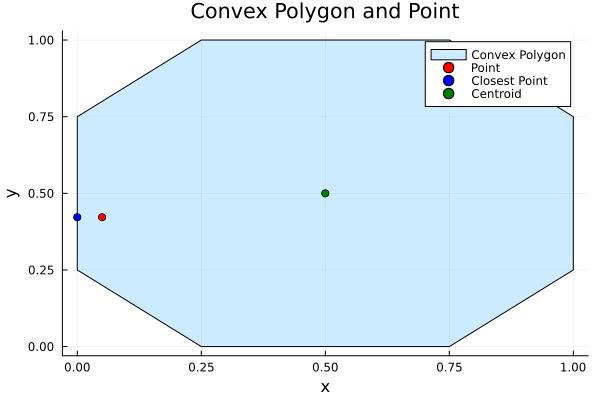

In [35]:
# Plot the polygon, the point, and the minimum distance as a line
plot_polygon_and_point(polygon, point, closest_point, centroid)

In [36]:
# Example (Blackboard)
p = [0.5, 0.5]
a = [0.5, 1]
b = [1,0]
d = b - a

pa = p - a
pa_d = dot(pa, d)
d_d = dot(d,d)
proj_length = pa_d/d_d
projection_point = a + proj_length*d

2-element Vector{Float64}:
 0.7
 0.6

In [42]:
speed = 1.8
vff = normal_vector * speed
min_safe_d = 0.1
u = [-1, -1]
norm(u)

1.4142135623730951

In [43]:
u_cmd = min(1, (distance/min_safe_d)) * u + max(0, (1 - (distance/min_safe_d)))*vff

2-element Vector{Float64}:
  0.38924471217748147
 -0.36127782490031285